In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
pd.set_option('display.max_columns', None)
import rasterio
import rasterio.mask as mask
import numpy as np
import os
import glob
import datetime
from matplotlib import font_manager
# Find the path to the Arial font
arial_font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'  # Update this path based on your system

# Add the Arial font to the font manager
font_manager.fontManager.addfont(arial_font_path)

# Set the font to Arial
plt.rcParams['font.family'] = 'Arial'


In [2]:
late = gpd.read_file('/mnt/sdc/landsat_senegal_data/shapes_and_masks/senegal_2017_2023_merged_cutlines_run7_clean_c4326.shp')
early = gpd.read_file('/mnt/sdc/landsat_senegal_data/shapes_and_masks/senegal_2002_2016_merged_cutlines_run7_clean_4326.shp_merged_cutlines_run7_clean_c4326.shp')

KeyboardInterrupt: 

In [15]:
late.columns

Index(['fid', 'level_0', 'level_1', 'IMAGENAME', 'SENSOR', 'ACQDATE', 'CAT_ID',
       'RESOLUTION', 'OFF_NADIR', 'SUN_ELEV', 'SUN_AZ', 'SAT_ELEV', 'SAT_AZ',
       'CLOUDCOVER', 'TDI', 'DATE_DIFF', 'SCORE', 'SCAN_DIR', 'RF_MULT',
       'RF_ADD', 'AOD', 'CLOUD_FRAC', 'STATS_MIN', 'STATS_MAX', 'STATS_STD',
       'STATS_MEAN', 'STATS_PCT', 'geometry'],
      dtype='object')

In [21]:
late["year"] = late["ACQDATE"].apply(lambda x: datetime.datetime.strptime(x, "%Y-%m-%dT%H:%M:%S.%fZ").year)
late["month"] = late["ACQDATE"].apply(lambda x: datetime.datetime.strptime(x, "%Y-%m-%dT%H:%M:%S.%fZ").month)
early["year"] = early["ACQDATE"].apply(lambda x: datetime.datetime.strptime(x, "%Y-%m-%dT%H:%M:%S.%fZ").year)
early["month"] = early["ACQDATE"].apply(lambda x: datetime.datetime.strptime(x, "%Y-%m-%dT%H:%M:%S.%fZ").month)

In [22]:
late.to_file('/mnt/sdc/landsat_senegal_data/shapes_and_masks/senegal_2017_2023_merged_cutlines_run7_clean_c4326_date.shp')
early.to_file('/mnt/sdc/landsat_senegal_data/shapes_and_masks/senegal_2002_2016_merged_cutlines_run7_clean_4326_date.shp')

In [ ]:
files_2000 = sorted(glob.glob('/mnt/sdd/downloads_on_drive_d/potapov/2000/*.tif'))
files_2020 = sorted(glob.glob('/mnt/sdd/downloads_on_drive_d/potapov/2020/*.tif'))

In [9]:
ag_pixels_2000 = []
ag_pixels_2020 = []

for file_2000 in files_2000:
    for file_2020 in files_2020:
        bn_2000 = os.path.basename(file_2000)
        bn_2020 = os.path.basename(file_2020)
        
        if bn_2000 == bn_2020:
            
            rst_2000 = rasterio.open(file_2000).read(1)
            rst_2020 = rasterio.open(file_2020).read(1)
            
            rst_2000 = np.where(rst_2000 == 244, 1, 0)
            rst_2020 = np.where(rst_2020 == 244, 1, 0)
            
            ag_pixels_2000.append(np.sum(rst_2000))
            ag_pixels_2020.append(np.sum(rst_2020))
            

In [10]:
ag_pixels_2000 = np.array(ag_pixels_2000).sum()
ag_pixels_2020 = np.array(ag_pixels_2020).sum()


In [11]:
ag_area_2000 = (ag_pixels_2000 * 30*30) / 1000000
ag_area_2020 = (ag_pixels_2020 * 30*30) / 1000000

In [12]:
print(ag_area_2000, ag_area_2020)
agg_diff = ag_area_2020 - ag_area_2000
print(agg_diff)

716243.9994 884087.091
167843.09160000004


In [34]:
ps_df = pd.read_csv('/home/rene1337/RSCPH/significant_trends_ls789_hct_trend_m2_ps_v4.csv')
ag_2000_df = pd.read_csv('/home/rene1337/RSCPH/significant_trends_ls789_hct_trend_m2_ag.csv')
ag_2020_df = pd.read_csv('/home/rene1337/RSCPH/significant_trends_ls789_hct_trend_m2_ag_2020.csv')
gdf = gpd.read_file('/home/rene1337/RSCPH/landsat_tree_analysis/significant_trends_ls789_wc_hct_trend_rainfall.gpkg')

In [35]:
ag_2000_df

,geometry,tile_id,country,region,pos_sig_diff,neg_sig_diff,pos_trend,neg_trend,pos_diff_m2,neg_diff_m2,pos_pixels,neg_pixels,total_pixels
0,POLYGON ((-3.2938227084382454 10.1809065533545...,-4_11_4,BFA,Sud-Ouest,0.000032,4.135573e-06,1.451745e-06,2.022491e-07,159.280230,20.436882,39002,6127,4941729
1,POLYGON ((-3.2938227084382454 10.4803449813944...,-4_11_7,BFA,Sud-Ouest,0.000087,5.944408e-06,3.798805e-06,3.125734e-07,432.171570,29.375654,97351,9909,4941729
2,POLYGON ((-2.9943842803984047 9.88146812531473...,-4_11_2,BFA,Sud-Ouest,0.000008,4.180608e-07,3.629654e-07,2.328678e-08,39.066257,2.066872,7313,505,4943952
3,POLYGON ((-2.9943842803984047 10.1809065533545...,-4_11_5,BFA,Sud-Ouest,0.000003,1.105954e-06,1.398359e-07,6.650396e-08,16.235699,5.467782,3991,2024,4943952
4,POLYGON ((-2.9943842803984047 10.4803449813944...,-4_11_8,BFA,Sud-Ouest,0.000012,1.821836e-06,4.949966e-07,1.074557e-07,57.051390,9.007070,15512,4226,4943952
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,POLYGON ((22.457882102988037 16.16967511415138...,25_18_0,TCD,Ennedi Est,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0,0,4943952
2194,POLYGON ((22.757320531027876 16.16967511415138...,25_18_1,TCD,Ennedi Est,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0,0,4946176
2195,POLYGON ((23.056758959067718 16.16967511415138...,25_18_2,TCD,Ennedi Est,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0,0,4943952
2196,POLYGON ((23.356197387107557 16.16967511415138...,26_18_0,TCD,Ennedi Est,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0,0,4943952


In [36]:
# where row = GMB rename to Gambia 

country_rename = [("GMB", "Gambia"), ("TGO", "Togo"), ("BFA", "Burkina Faso"),
 ("BEN", "Benin"), ("GIN", "Guinea"), ("GHA", "Ghana"),
 ("MLI", "Mali"), ("NER", "Niger"), ("NGA", "Nigeria"),
 ("SEN", "Senegal"), ("TCD", "Chad"), ("CIV", "Côte d'Ivoire"),
 ("ETH", "Ethiopia"), ("ERI", "Eritrea"), ("SDN", "Sudan"),
 ("CMR", "Cameroon"), ("CAF", "Central African Republic"), ("SSD", "South Sudan"), ("DJI", "Djibouti"),
 ("MRT", "Mauritania")]

for i, j in country_rename:
    ps_df.loc[ps_df['country'] == i, 'country'] = j
    ag_2000_df.loc[ag_2000_df['country'] == i, 'country'] = j
    ag_2020_df.loc[ag_2020_df['country'] == i, 'country'] = j


In [37]:

# Set the display option to avoid scientific notation
pd.set_option('display.float_format', '{:.6f}'.format)

df = ag_2000_df
#df['neg_area_km2'] = (df['neg_pixels']*215)/1000000
#df['pos_area_km2'] = (df['pos_pixels']*215)/1000000
#df['neg_area_ha'] = (df['neg_pixels']*215)/10000
#df['pos_area_ha'] = (df['pos_pixels']*215)/10000
#df['total_area'] = (df['total_pixels']*215)/1000000
#df["pos_diff_km2"] = df['pos_diff_m2'] / 100
#df["neg_diff_km2"] = df['neg_diff_m2'] / 100
df["pos_diff_hct"] = df['pos_diff_m2']
df["neg_diff_hct"] = df['neg_diff_m2']
df["net_tree_cover_change_ha"] = df["pos_diff_hct"] - df["neg_diff_hct"]
pixel_area_ha = (15 * 15) / 10_000  # = 0.0225 hectares per pixel

df["cropland_area_ha"] = df["pos_pixels"] + df["neg_pixels"]
df["cropland_area_ha"] *= pixel_area_ha
df["percent_net_change"] = 100 * df["net_tree_cover_change_ha"] / df["cropland_area_ha"]
df["percent_increase"] = 100 * df["pos_diff_hct"] / df["cropland_area_ha"]
df["percent_decrease"] = 100 * df["neg_diff_hct"] / df["cropland_area_ha"]

#total_area = 
#print(f'Total area: {total_area} km2')
#df["total_area"] = total_area
#df["percent_positive"] = (df["pos_area"]/df["total_area"])*100
#df["percent_negative"] = (df["neg_area"]/df["total_area"])*100
df_dropped = df.drop(columns=['geometry', 'tile_id', 'country', 'region'])

df_sum = df_dropped.sum()
total_area = (df_sum['total_pixels']*215)/1000000
ag_2000_df = df

/tmp/ipykernel_1643345/941198307.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_country = df.groupby(['country']).sum()


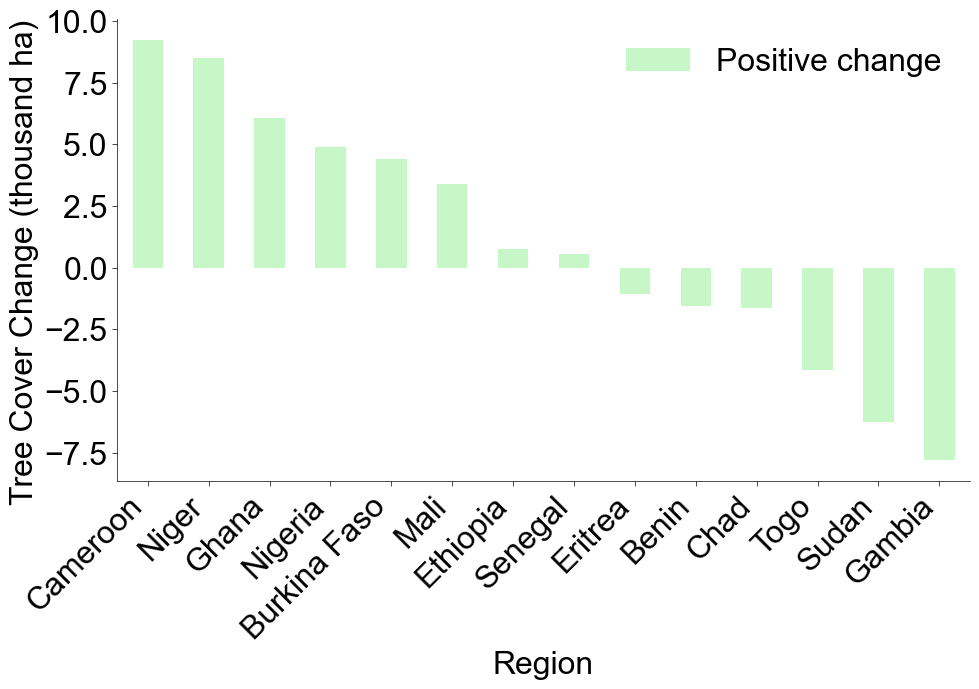

In [65]:
df_country = df.groupby(['country']).sum()
df_country["net_change_ha"] = df_country["pos_diff_hct"] - df_country["neg_diff_hct"]
df_country["percent_net_change"] = 100 * df_country["net_change_ha"] / df_country["cropland_area_ha"]
df_country["percent_positive"] = (df_country["pos_diff_hct"] / df_country["cropland_area_ha"]) * 100
df_country["percent_negative"] = (df_country["neg_diff_hct"] / df_country["cropland_area_ha"]) * 100

# remove rows where country == mrt
df_country = df_country[df_country.index != 'Mauritania']
df_country = df_country[df_country.index != 'Djibouti']
df_country = df_country[df_country.index != 'South Sudan']
df_country = df_country[df_country.index != 'Central African Republic']

# group to Niger 
df_niger = df_country

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(11, 6))
df_niger.sort_values(by='percent_net_change', ascending=False, inplace=True)
df_niger.plot(kind='bar', y='percent_net_change', ax=ax, alpha=0.5, color='lightgreen')
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
fontsize=23
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)    

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

plt.ylabel('Tree Cover Change (thousand ha)', fontsize=fontsize, loc='top')
plt.xlabel('Region', fontsize=fontsize)
plt.legend(['Positive change', 'Negative change'], frameon=False, fontsize=fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
#plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789_.png', dpi=1000, bbox_inches='tight')
# save figures as vector graphics
#plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789.svg', bbox_inches='tight')
plt.show()


In [154]:
regions_gdf = gpd.read_file("/home/rene1337/RSCPH/landsat_tree_analysis/wrl_polbnd_adm2_a_unhcr.gpkg")  # example: Admin 1 for Niger
regions_gdf["region"] = regions_gdf["gis_name"].str.lower().str.strip()
regions_gdf["country"] = regions_gdf["Country_territory__ISO3_"].str.lower().str.strip()
regions_gdf['country_region'] = regions_gdf['country'] + '_' + regions_gdf['region']

In [121]:
regions_gdf = gpd.read_file("/home/rene1337/RSCPH/landsat_tree_analysis/glob_lvl1_admin_boundaries.gpkg")  # example: Admin 1 for Niger
regions_gdf["region"] = regions_gdf["gis_name"].str.lower().str.strip()
regions_gdf["country"] = regions_gdf["Country_territory__ISO3_"].str.lower().str.strip()
regions_gdf['country_region'] = regions_gdf['country'] + '_' + regions_gdf['region']


In [150]:
df = ag_2000_df.groupby(['country', 'region']).sum()
df["net_change_ha"] = df["pos_diff_hct"] - df["neg_diff_hct"]
df["percent_net_change"] = 100 * df["net_change_ha"] / df["cropland_area_ha"]
df["percent_positive"] = (df["pos_diff_hct"] / df["cropland_area_ha"]) * 100
df["percent_negative"] = (df["neg_diff_hct"] / df["cropland_area_ha"]) * 100
df.reset_index(inplace=True)
df['region'] = df['region'].str.lower().str.strip()
df['country'] = df['country'].str.lower().str.strip()
df['country_region'] = df['country'] + '_' + df['region']

relevant_countries = df["country_region"].unique()
print(len(relevant_countries))
relevant_regions = df["region"].unique()
# add elements to np array 
relevant_countries = np.append(relevant_countries, ['mrt_guidimagha', 'mrt_hodh chargui', "tcd_n'djamena", "tcd_guéra", "tcd_ouaddaï", "tcd_tandjilé"])

country_subset = regions_gdf[regions_gdf["country_region"].str.lower().str.strip().isin(relevant_countries)].copy()
subset_gdf = country_subset[country_subset["region"].isin(relevant_regions)].copy()

print(sorted(relevant_countries))
print(sorted(country_subset['country_region'].unique()))

#print(sorted(relevant_countries))
#print(sorted(df['country_region'].unique()))
#print(sorted(country_subset['country_region'].unique()))
#print(sorted(regions_gdf['country_region'][regions_gdf['country'] == 'tcd'].unique()))

print(len(country_subset['country_region'].unique()))

# print the difference bewtween two lists 
#print(set(df['country_region'].unique()) - set(country_subset['country_region'].unique()))

98
['ben_alibori', 'ben_atacora', 'bfa_boucle du mouhoun', 'bfa_centre', 'bfa_centre-est', 'bfa_centre-nord', 'bfa_centre-ouest', 'bfa_centre-sud', 'bfa_est', 'bfa_hauts-bassins', 'bfa_nord', 'bfa_plateau central', 'bfa_sahel', 'bfa_sud-ouest', 'caf_vakaga', 'cmr_extreme-nord', 'eri_debub', 'eri_gash barka', 'eri_maekel', 'eri_semenawi keih bahri', 'eth_afar', 'eth_amhara', 'eth_benishangul gumz', 'eth_tigray', 'gha_northern', 'gha_northern east', 'gha_upper east', 'gha_upper west', 'gmb_kuntaur', 'mli_kayes', 'mli_koulikouro', 'mli_mopti', 'mli_segou', 'mli_sikasso', 'mli_tombouctou', 'mrt_assaba', 'mrt_guidimagha', 'mrt_guidimakha', 'mrt_hodh chargi', 'mrt_hodh chargui', 'mrt_hodh el gharbi', 'ner_agadez', 'ner_diffa', 'ner_dosso', 'ner_maradi', 'ner_tahoua', 'ner_tillabéri', 'ner_zinder', 'nga_adamawa', 'nga_bauchi', 'nga_borno', 'nga_gombe', 'nga_jigawa', 'nga_kano', 'nga_katsina', 'nga_kebbi', 'nga_niger', 'nga_sokoto', 'nga_yobe', 'nga_zamfara', 'sdn_aj jazirah', 'sdn_blue nile',

/tmp/ipykernel_1643345/690041907.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = ag_2000_df.groupby(['country', 'region']).sum()


In [155]:
relevant_countries = df["country"].unique()
level2_subset = regions_gdf[regions_gdf["country"].str.lower().str.strip().isin(relevant_countries)].copy()

In [158]:
level2_subset.to_file('/home/rene1337/RSCPH/landsat_tree_analysis/level2_subset.gpkg', driver='GPKG')

In [ ]:
#'tcd_tandjile', 'tcd_guera', 'tcd_ouaddai', 'mrt_guidimakha', 'tcd_ndjamena'

In [151]:
choropleth_gdf = country_subset.merge(df, on=["region"], how="left")

In [152]:
print(choropleth_gdf[choropleth_gdf['region'] == 'maradi'])

    OBJECTID Country_territory__ISO3_     pcode gis_name adm1_source_code  \
61      5914                      NER  22NER004   Maradi            NE004   

   focus_id progres_id  gis_status  \
61                              14   

                                            source   src_date      mod_by  \
61  IGNN (as of 2006) and OCHA/ROWCA ( 2014/ 2015) 2006-01-01  OCHA Niger   

     mod_date     update_by         update_date comments  \
61 2023-12-26  UNHCR_WRITER 2024-01-10 15:25:32            

                                  globalid  created_user        created_date  \
61  {C86CAFCD-36CA-475B-92DD-3A8EE49411EF}  UNHCR_WRITER 2024-01-10 15:25:32   

   start_date  end_date     st_area_shape_  st_length_shape_  \
61 2024-01-01       NaN 41994223798.857346     963336.694934   

                                             geometry  region country_x  \
61  MULTIPOLYGON (((7.76947 14.42108, 7.82971 14.4...  maradi       ner   

   country_region_x country_y  pos_sig_diff  neg_si

In [153]:
choropleth_gdf.to_file('/home/rene1337/RSCPH/landsat_tree_analysis/tree_cover_change_by_region.gpkg')

In [30]:
gdf = gpd.read_file('/home/rene1337/RSCPH/landsat_tree_analysis/level2_zonal_stats.gpkg').to_crs(epsg=3857)
#vrt = rasterio.open("/mnt/sdd/ls789gf/trend_silver_sweep_9_ag_2000.vrt").read(5)

In [31]:
# get the value of gdf["sum"] relative to the area of the polygon
# for each row in gdf, get the area of the polygon and divide the value of
gdf["area_km2"] = gdf.geometry.area / 1e6  # convert area to square kilometers
#gdf.fillna(0, inplace=True)  # fill NaN values with 0
gdf["relative_sum"] = gdf["_sum"] /   gdf['area_km2'] # convert to per hectare
gdf.drop(columns=['update_date', 'start_date'], inplace=True)

In [32]:
gdf.to_file('/home/rene1337/RSCPH/landsat_tree_analysis/level2_zonal_stats_relative.gpkg', driver='GPKG')

In [38]:
df = ag_2000_df #ps_df #ag_2000_df #ag_2020_df
df['neg_area'] = (df['neg_pixels']*215)/10000000000
df['pos_area'] = (df['pos_pixels']*215)/10000000000
df['total_area'] = (df['total_pixels']*215)/10000
df["pos_diff_km2"] = df['pos_diff_m2'] / 100
df["neg_diff_km2"] = df['neg_diff_m2'] / 100
df["pos_diff_hct"] = df['pos_diff_m2'] / 1000
df["neg_diff_hct"] = df['neg_diff_m2'] / 1000
df["net_diff_hct"] = df["pos_diff_hct"] - df["neg_diff_hct"]
df_dropped = df.drop(columns=['geometry', 'tile_id', 'country', 'region'])
df_sum = df_dropped.sum()
total_area = (df_sum['total_pixels']*215)/1000000
print(f'Total area: {total_area} km2')
df["total_area"] = total_area
df["percent_positive"] = (df["pos_area"]/df["total_area"])*100
df["percent_negative"] = (df["neg_area"]/df["total_area"])*100

# group df by region but retain the country
df_region_sum = df.groupby(['region', 'country']).sum()
df_region_count = df.groupby(['region', 'country']).count()

df_country_sum = df.groupby(['country']).sum()
df_country_count = df.groupby(['country']).count()

# remove rows where country == mrt
df_country_sum = df_country_sum[df_country_sum.index != 'MRT']
df_country_sum = df_country_sum[df_country_sum.index != 'DJI']
df_country_sum = df_country_sum[df_country_sum.index != 'SSD']
df_country_sum = df_country_sum[df_country_sum.index != 'CAF']

df_region = df_region_sum #.div(total_area)
df_country = df_country_sum #.div(total_area)

df_region.sort_values(by="country", ascending=False, inplace=True)
#df_region.reset_index(inplace=True)
df_region["country"] = df_region.index.get_level_values(1)
df_region["region"] = df_region.index.get_level_values(0)
#df_region.reset_index(inplace=True)
df_region.set_index('region', inplace=True)

ag_2000_df = df


Total area: 2335771.72309 km2


/tmp/ipykernel_2318727/2807420287.py:19: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_region_sum = df.groupby(['region', 'country']).sum()
/tmp/ipykernel_2318727/2807420287.py:22: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_country_sum = df.groupby(['country']).sum()


In [45]:
pos_diff_km2 = df_sum['pos_diff_m2'] / 100
neg_diff_km2 = df_sum['neg_diff_m2'] / 100
df_sum["pos_diff_km2"] = pos_diff_km2
df_sum["neg_diff_km2"] = neg_diff_km2
print(f'Positive change in tree cover: {pos_diff_km2} km2')
print(f'Negative change in tree cover: {neg_diff_km2} km2')

pos_area = (df_sum['pos_pixels']*215)/1000000
neg_area = (df_sum['neg_pixels']*215)/1000000
print(f'Positive area: {pos_area} km2')
print(f'Negative area: {neg_area} km2')

total_area = (df_sum['total_pixels']*215)/1000000
print(f'Total area: {total_area} km2')

pos_percent_of_sahel = pos_area/total_area * 100
neg_percent_of_sahel = neg_area/total_area * 100
print(f'Positive area as % of Sahel: {pos_percent_of_sahel}')
print(f'Negative area as % of Sahel: {neg_percent_of_sahel}')

print(f'Positive change in tree cover as % of Sahel: {df_sum["pos_diff_km2"]/3053200 * 100}')

Positive change in tree cover: 13373.830201605895 km2
Negative change in tree cover: 16926.82204179649 km2
Positive area: 96431.915455 km2
Negative area: 117837.2344 km2
Total area: 2335771.72309 km2
Positive area as % of Sahel: 4.128482013106568
Negative area as % of Sahel: 5.04489515114571
Positive change in tree cover as % of Sahel: 0.4380266671559641


In [40]:
#ps_df_country = ps_df.groupby(['country']).sum()
ag_2000_df_country = ag_2000_df.groupby(['country']).sum()
#ag_2020_df_country = ag_2020_df.groupby(['country']).sum()

#pos_diff_ha_ps = ps_df_country['pos_diff_hct']
#neg_diff_ha_ps = ps_df_country['neg_diff_hct']

pos_diff_ha_ag_2000 = ag_2000_df_country['pos_diff_hct']
neg_diff_ha_ag_2000 = ag_2000_df_country['neg_diff_hct']

#pos_diff_ha_ag_2020 = ag_2020_df_country['pos_diff_hct']
#neg_diff_ha_ag_2020 = ag_2020_df_country['neg_diff_hct']

'''df = pd.concat([pos_diff_ha_ps, neg_diff_ha_ps, 
                    pos_diff_ha_ag_2000, neg_diff_ha_ag_2000, 
                    pos_diff_ha_ag_2020, neg_diff_ha_ag_2020], 
                   axis=1)'''

df = pd.concat([pos_diff_ha_ag_2000, neg_diff_ha_ag_2000], 
                   axis=1)

df.columns = ['pos_diff_ha_ag_2000', 'neg_diff_ha_ag_2000']

/tmp/ipykernel_2318727/1794187553.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ag_2000_df_country = ag_2000_df.groupby(['country']).sum()


KeyError: "['pos_diff_ha_ag_2020', 'pos_diff_ha_ps'] not in index"

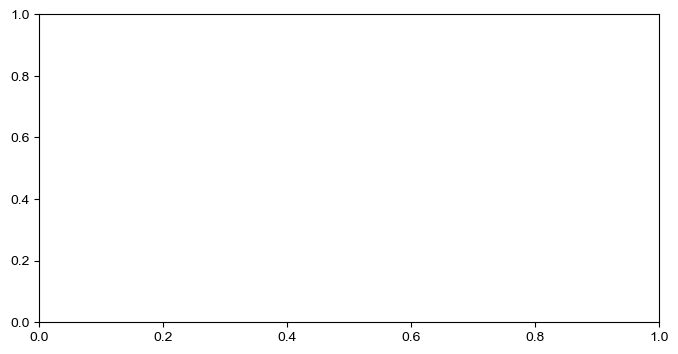

In [40]:
df
# remove rows where country == mrt
df = df[df.index != 'Djibouti']
df = df[df.index  != 'South Sudan']
df = df[df.index  != 'Central African Republic']
df = df[df.index  != 'Togo']
df = df[df.index  != 'Ghana']
df = df[df.index  != 'Benin']

df_country = df


# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_ha_ag_2000', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_diff_ha_ag_2000', 'pos_diff_ha_ag_2020', 'pos_diff_ha_ps'], 
                ax=ax, alpha=0.5, color=['darkgreen', 'limegreen', 'lightgreen'], legend=False)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line
plt.legend(['Landuse (2000)', 'Landuse (2020)', 'Trees'], fontsize=13, frameon=False)
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Tree Cover Increase (thousand ha)', fontsize=13)
plt.xlabel('Country', fontsize=13)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_increase_landuse.png', dpi=1000, bbox_inches='tight')

# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_increase_landuse.svg', bbox_inches='tight')

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_ha_ag_2000', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['neg_diff_ha_ag_2000', 'neg_diff_ha_ag_2020', 'neg_diff_ha_ps'], 
                ax=ax, alpha=0.5, color=['darkred', 'red', 'lightcoral'], legend=False)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

#set font ot arial
plt.rcParams['font.family'] = 'Arial'

# 0 line
plt.legend(['Landuse (2000)', 'Landuse (2020)', 'Trees'], fontsize=13, frameon=False)
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)

plt.ylabel('Tree Cover Decrease (thousand ha)', fontsize=13)
plt.xlabel('Country', fontsize=13)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_decrease_landuse.png', dpi=1000, bbox_inches='tight')


# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_decrease_landuse.svg', bbox_inches='tight')

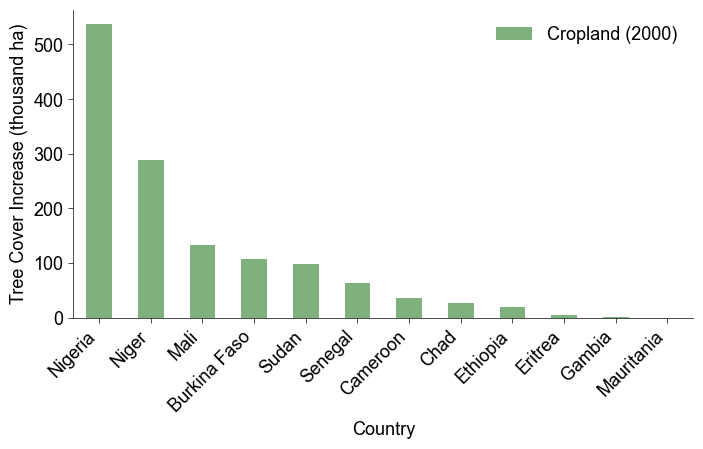

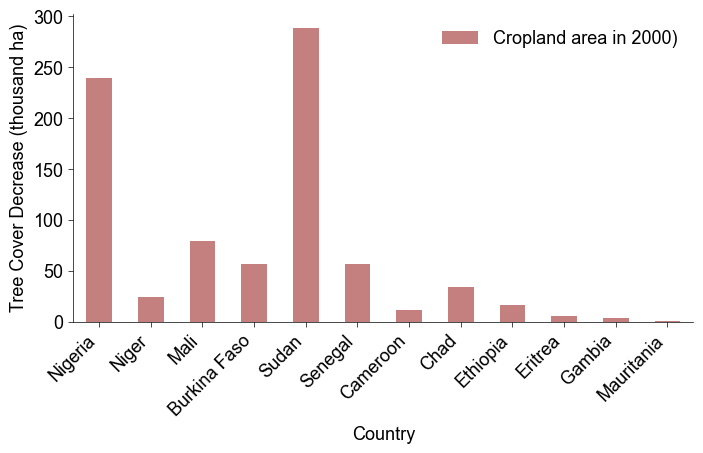

In [41]:
df
# remove rows where country == mrt
df = df[df.index != 'Djibouti']
df = df[df.index  != 'South Sudan']
df = df[df.index  != 'Central African Republic']
df = df[df.index  != 'Togo']
df = df[df.index  != 'Ghana']
df = df[df.index  != 'Benin']

df_country = df


# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_ha_ag_2000', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_diff_ha_ag_2000'], 
                ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'], legend=False)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

# 0 line
plt.legend(['Cropland (2000)', 'Cropland (2020)'], fontsize=13, frameon=False)
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)
#set font ot arial
#set font ot arial
plt.rcParams['font.family'] = 'Arial'

plt.ylabel('Tree Cover Increase (thousand ha)', fontsize=13)
plt.xlabel('Country', fontsize=13)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_increase_landuse.png', dpi=1000, bbox_inches='tight')

# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_increase_landuse.svg', bbox_inches='tight')

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_ha_ag_2000', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['neg_diff_ha_ag_2000'], 
                ax=ax, alpha=0.5, color=['darkred', 'red'], legend=False)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

#set font ot arial
plt.rcParams['font.family'] = 'Arial'

# 0 line
plt.legend(['Cropland area in 2000)', 'Cropland area in 2020'], fontsize=13, frameon=False)
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)

plt.ylabel('Tree Cover Decrease (thousand ha)', fontsize=13)
plt.xlabel('Country', fontsize=13)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_decrease_landuse.png', dpi=1000, bbox_inches='tight')


# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_decrease_landuse.svg', bbox_inches='tight')

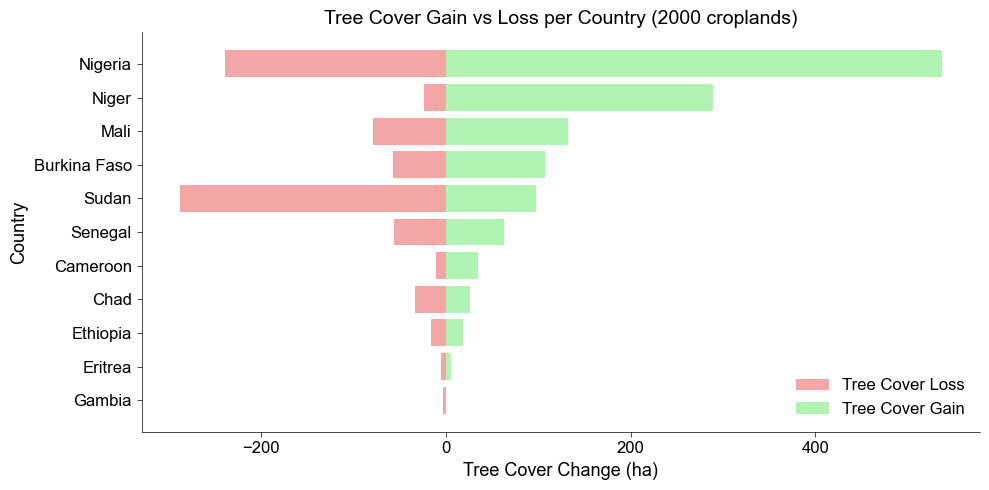

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter out unwanted countries
df = df[~df.index.isin(['Djibouti', 'South Sudan', 'Central African Republic', 'Togo', 'Ghana', 'Benin', 'Mauritania'])]

# Create a working copy
df_country = df.copy()

# Sort by gain (or net change) to order bars
df_country.sort_values(by='pos_diff_ha_ag_2000', ascending=True, inplace=True)

# Create gain and loss columns (loss must be negative for diverging bars)
gains = df_country['pos_diff_ha_ag_2000']
losses = -df_country['neg_diff_ha_ag_2000']  # negative for left bars
countries = df_country.index

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(countries, losses, color='lightcoral', alpha=0.7, label='Tree Cover Loss')
ax.barh(countries, gains, color='lightgreen', alpha=0.7, label='Tree Cover Gain')

# Add vertical line at zero
#ax.axvline(0, color='black', linewidth=0.8)

# Formatting
ax.set_xlabel('Tree Cover Change (ha)', fontsize=13)
ax.set_ylabel('Country', fontsize=13)
ax.set_title('Tree Cover Gain vs Loss per Country (2000 croplands)', fontsize=14)
ax.legend(loc='lower right', fontsize=12, frameon=False)

# Aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.tick_params(axis='both', colors='black', width=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.rcParams['font.family'] = 'Arial'

'''# Optional: annotate values
for i, country in enumerate(countries):
    if gains.iloc[i] > 0:
        ax.text(gains.iloc[i] + 10000, i, f'{int(gains.iloc[i] / 1000)}k', va='center', ha='left', fontsize=9)
    if losses.iloc[i] < 0:
        ax.text(losses.iloc[i] - 10000, i, f'{int(abs(losses.iloc[i]) / 1000)}k', va='center', ha='right', fontsize=9)
'''
# Save
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none' 
#plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_diverging_gain_loss.png', dpi=1000, bbox_inches='tight')
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_diverging_gain_loss.svg', bbox_inches='tight')
plt.show()


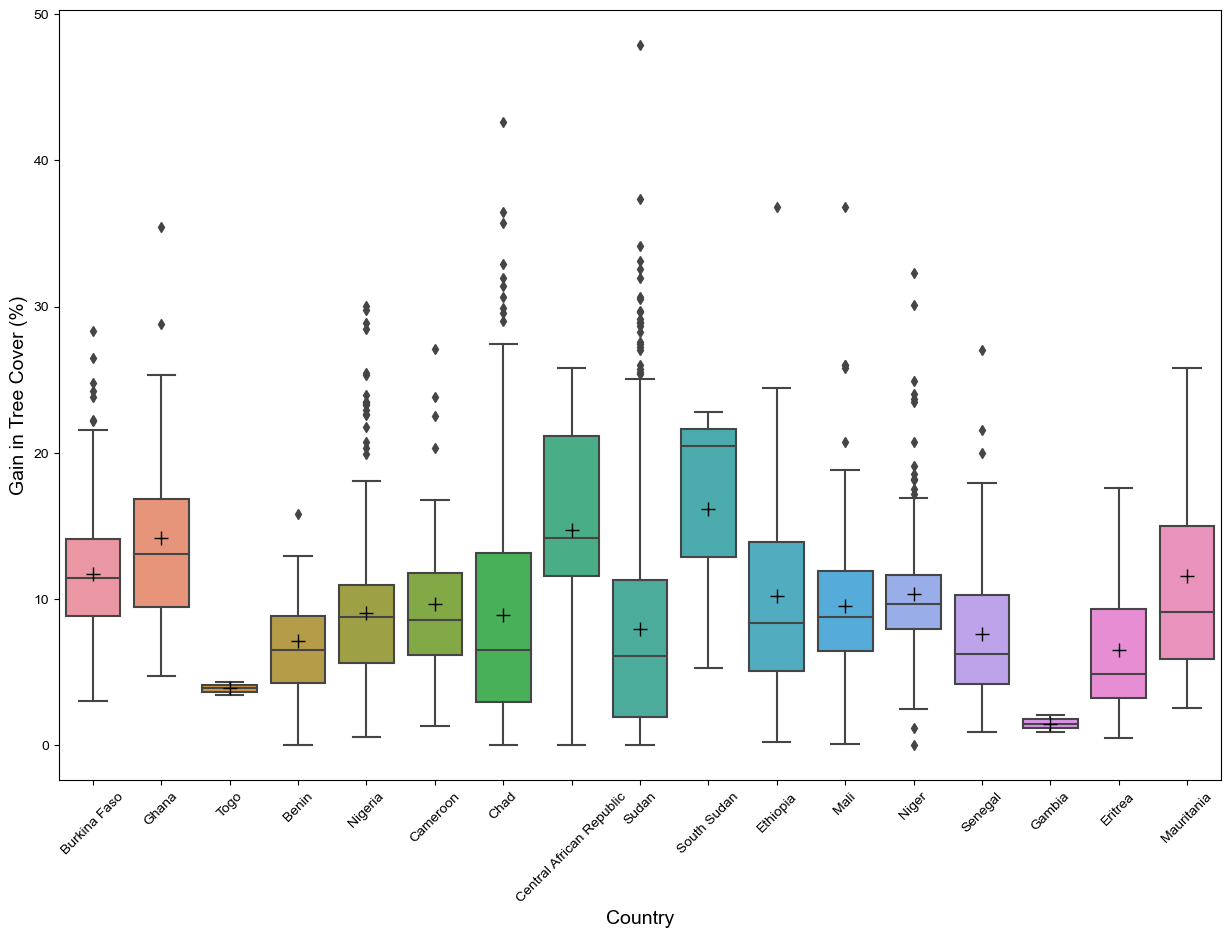

In [61]:
import seaborn as sns
# Create the box plot
fig, ax = plt.subplots(figsize=(15, 10))
# plot mean on box plot
sns.boxplot(x='country', y='percent_increase', data=ag_2000_df, ax=ax, showmeans=True, meanprops={'marker':'+', 'markeredgecolor':'black', 'markersize':'10'}) 
#sns.boxplot(x='country_x', y='Mean Positive Significant Difference', hue='Type', data=df_melted, ax=ax, legend=True)

# change legend text
#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles=handles[0:], labels=['Cropland', 'Shrubland'], title='Land Cover Type')

# Add labels and rotate x-axis labels
plt.xlabel('Country', fontsize=14)
plt.ylabel('Gain in Tree Cover (%)', fontsize=14)

plt.xticks(rotation=45)

# Show the plot
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/methods/boxplot_pos_sig_diff_300.svg', bbox_inches='tight')

In [ ]:
# group df by region but retain the country
df_region_sum = df.groupby(['region', 'country']).sum()
df_region_count = df.groupby(['region', 'country']).count()

df_country_sum = df.groupby(['country']).sum()
df_country_count = df.groupby(['country']).count()

# remove rows where country == mrt
df_country_sum = df_country_sum[df_country_sum.index != 'MRT']
df_country_sum = df_country_sum[df_country_sum.index != 'DJI']
df_country_sum = df_country_sum[df_country_sum.index != 'SSD']
df_country_sum = df_country_sum[df_country_sum.index != 'CAF']

df_region = df_region_sum #.div(total_area)
df_country = df_country_sum #.div(total_area)

df_region.sort_values(by="country", ascending=False, inplace=True)
#df_region.reset_index(inplace=True)
df_region["country"] = df_region.index.get_level_values(1)
df_region["region"] = df_region.index.get_level_values(0)
#df_region.reset_index(inplace=True)
df_region.set_index('region', inplace=True)

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
# 0 line
plt.legend(['Positive Change', 'Negative Change'])
#plt.axhline(y=0, color='darkgreen', linestyle='--', alpha = 0.5)

plt.ylabel('Tree Cover Change (ha)')
plt.xlabel('Country')

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_new_percent_ps.png', dpi=1000, bbox_inches='tight')
plt.show()

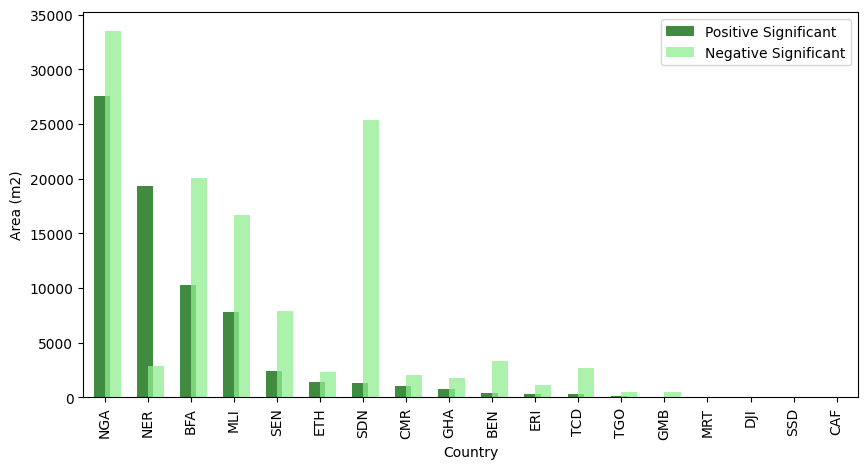

In [58]:
# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='pos_area', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_area', 'neg_area'], ax=ax, alpha=0.75, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)

plt.ylabel('Area (m2)')
plt.xlabel('Country')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()

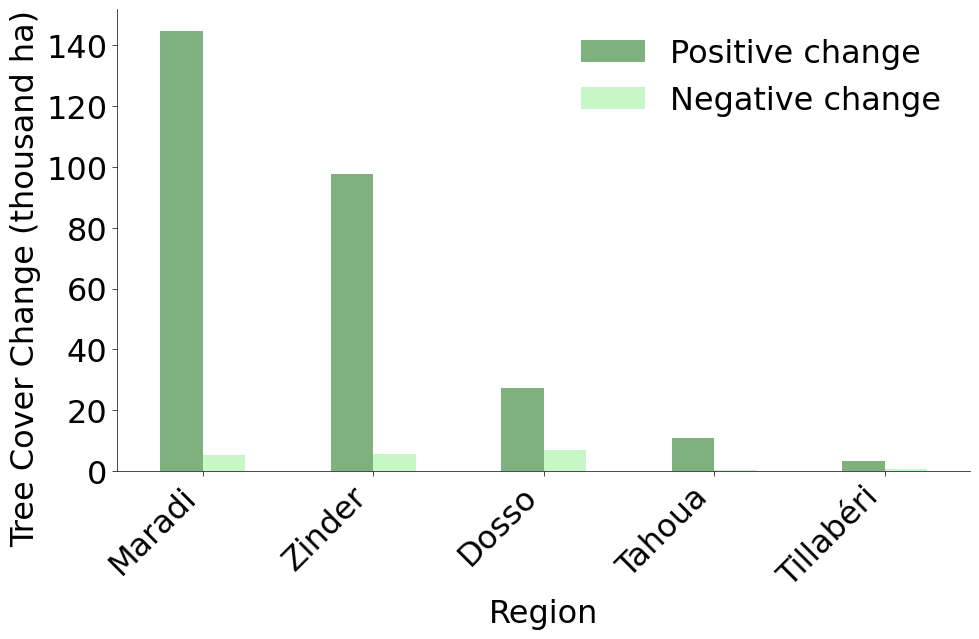

In [25]:

# group to Niger 
df_niger = df_region[df_region['country'] == 'Niger']

# remove rows where country == mrt
df_niger = df_niger[df_niger.index != 'Diffa']
df_niger = df_niger[df_niger.index != 'Agadez']

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(11, 6))
df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
fontsize=23
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)    

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

plt.ylabel('Tree Cover Change (thousand ha)', fontsize=fontsize, loc='top')
plt.xlabel('Region', fontsize=fontsize)
plt.legend(['Positive change', 'Negative change'], frameon=False, fontsize=fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789_.png', dpi=1000, bbox_inches='tight')
# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789.svg', bbox_inches='tight')
plt.show()

In [67]:
df_region.to_csv('/home/rene1337/RSCPH/landsat_tree_analysis/Sahel_tree_cover_regions.csv')

In [74]:
df_niger.head()

,pos_sig_diff,neg_sig_diff,pos_trend,neg_trend,pos_diff_m2,neg_diff_m2,pos_pixels,neg_pixels,total_pixels,neg_area,pos_area,total_area,pos_diff_km2,neg_diff_km2,pos_diff_hct,neg_diff_hct,net_diff_hct,percent_positive,percent_negative,country
region,,,,,,,,,,,,,,,,,,,,
Maradi,0.029256,0.001104,0.001561,0.000053,144607.827118,5455.316645,67292952,3672300,202657575,0.078954,1.446798,9.576664e+07,1446.078271,54.553166,144.607827,5.455317,139.152510,0.000062,3.380230e-06,Niger
Zinder,0.019738,0.001129,0.001027,0.000061,97563.990715,5581.279769,40434709,3935524,360821803,0.084614,0.869346,1.705113e+08,975.639907,55.812798,97.563991,5.581280,91.982711,0.000037,3.622519e-06,Niger
Dosso,0.005512,0.001421,0.000284,0.000071,27240.548733,7025.170550,8981942,2523784,158162005,0.054261,0.193112,7.474470e+07,272.405487,70.251705,27.240549,7.025171,20.215378,0.000008,2.323059e-06,Niger
Tahoua,0.002192,0.000096,0.000129,0.000004,10833.289061,474.273563,4959224,332936,93910636,0.007158,0.106623,4.437966e+07,108.332891,4.742736,10.833289,0.474274,10.359015,0.000005,3.064565e-07,Niger
Tillabéri,0.000699,0.000151,0.000041,0.000007,3455.736871,748.419818,1255885,404023,172984969,0.008686,0.027002,8.175201e+07,34.557369,7.484198,3.455737,0.748420,2.707317,0.000001,3.718897e-07,Niger


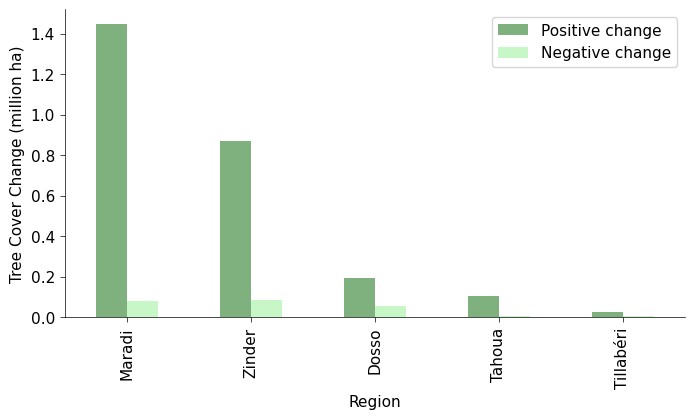

In [52]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'NER']

# remove rows where country == mrt
df_niger = df_niger[df_niger.index != 'Diffa']
df_niger = df_niger[df_niger.index != 'Agadez']

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(8, 4))
df_niger.sort_values(by='pos_area', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_area', 'neg_area'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)    

plt.ylabel('Tree Cover Change (million ha)', fontsize=11)
plt.xlabel('Region', fontsize=11)
plt.legend(['Positive change', 'Negative change'], fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
#plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789_ps.png', dpi=1000, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1536219/43549381.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)


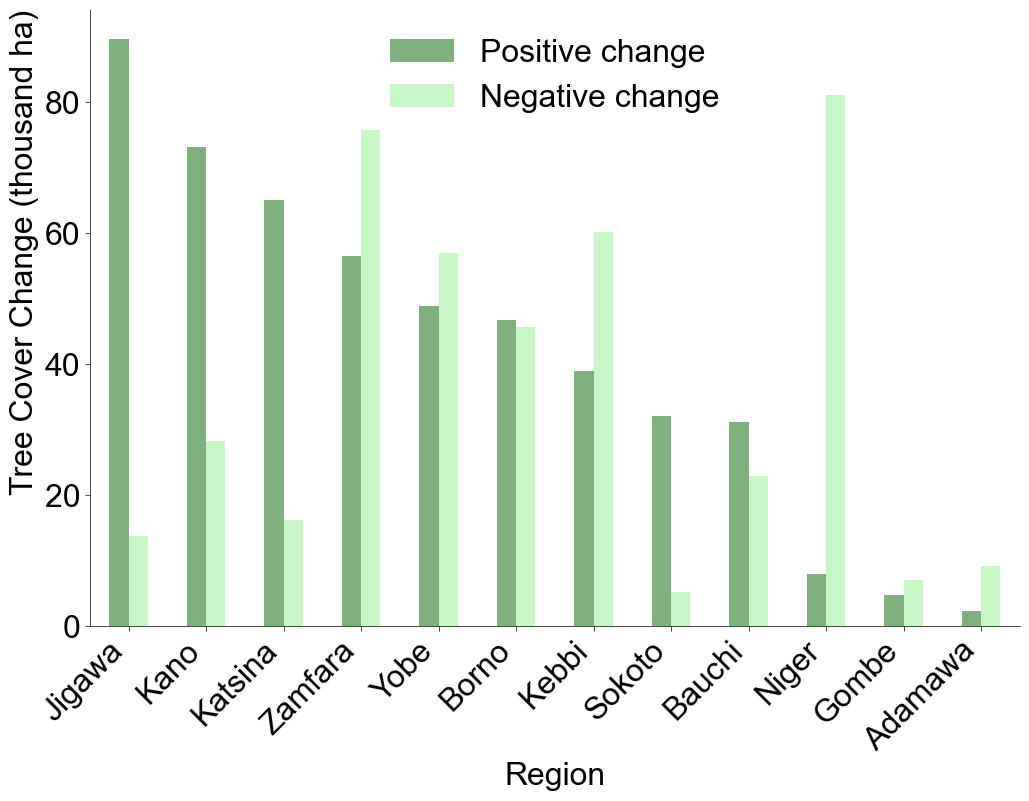

In [53]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'Nigeria']



# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(12, 8))
df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
fontsize=23
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)    

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

plt.ylabel('Tree Cover Change (thousand ha)', fontsize=fontsize, loc='top')
plt.xlabel('Region', fontsize=fontsize)
plt.legend(['Positive change', 'Negative change'], frameon=False, fontsize=fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/nigeria_bars_ls789_.png', dpi=1000, bbox_inches='tight')
# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/nigeria_bars_ls789.svg', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1536219/3676825376.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)


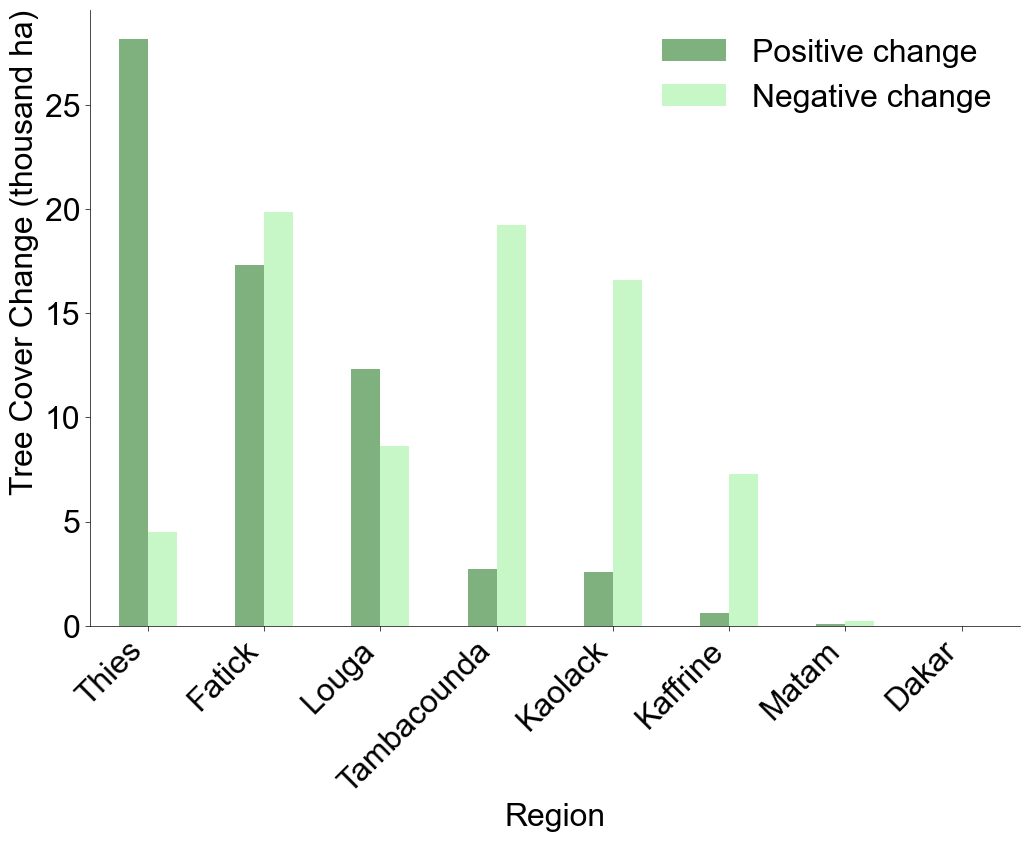

In [ ]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'Senegal']

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(12, 8))
df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
fontsize=23
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)    

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

plt.ylabel('Tree Cover Change (thousand ha)', fontsize=fontsize, loc='top')
plt.xlabel('Region', fontsize=fontsize)
plt.legend(['Positive change', 'Negative change'], frameon=False, fontsize=fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/Senegal_bars_ls789_.png', dpi=1000, bbox_inches='tight')
# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/senegal_bars_ls789.svg', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1536219/3909979441.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)


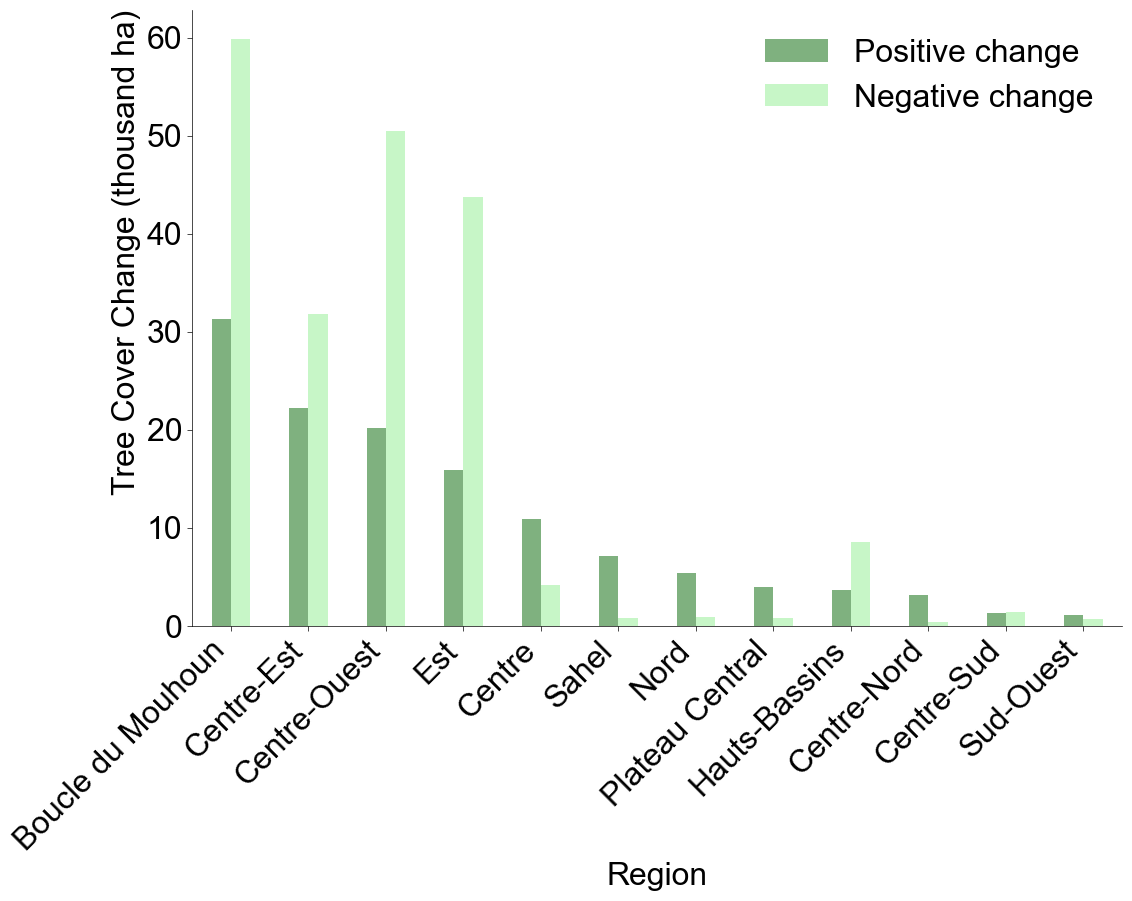

In [56]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'Burkina Faso']



# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(12, 8))
df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
fontsize=23
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)    

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

plt.ylabel('Tree Cover Change (thousand ha)', fontsize=fontsize, loc='top')
plt.xlabel('Region', fontsize=fontsize)
plt.legend(['Positive change', 'Negative change'], frameon=False, fontsize=fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/burk_bars_ls789_.png', dpi=1000, bbox_inches='tight')
# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/burk_bars_ls789.svg', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1536219/2480862885.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)


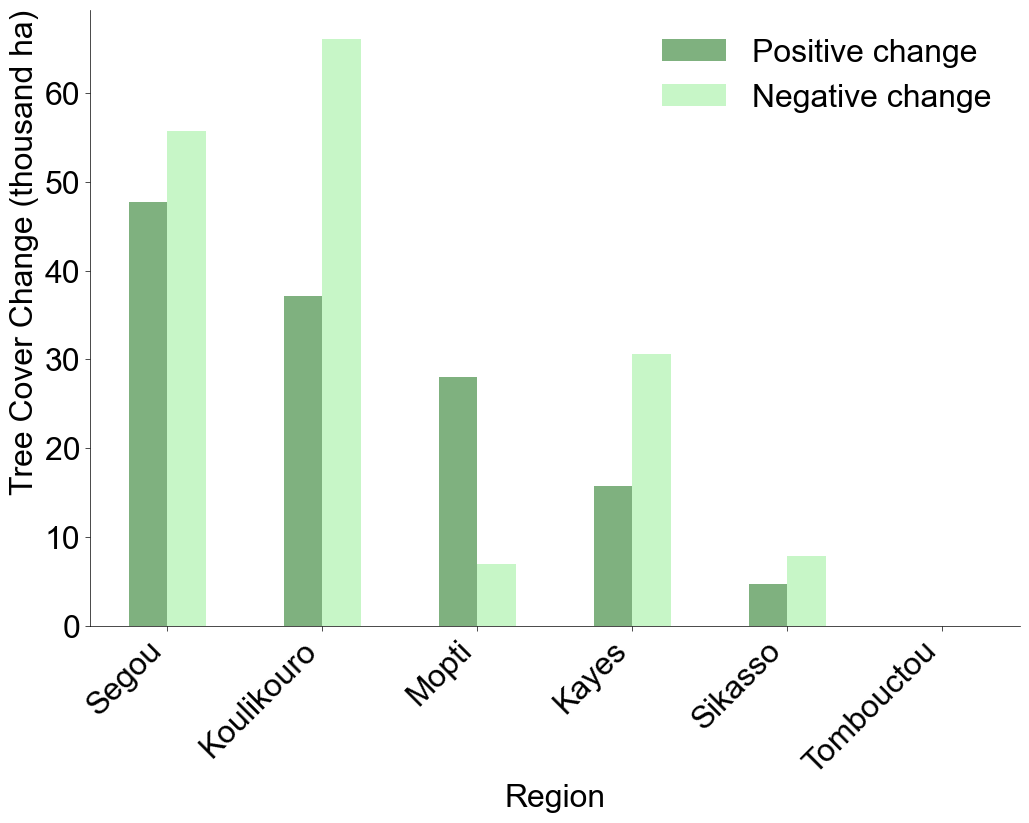

In [57]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'Mali']

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(12, 8))
df_niger.sort_values(by='pos_diff_hct', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_hct', 'neg_diff_hct'], ax=ax, alpha=0.5, color=['darkgreen', 'lightgreen'])
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1)
fontsize=23
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)    

# set x axis labels as diagonal
plt.xticks(rotation=45, ha='right')

plt.ylabel('Tree Cover Change (thousand ha)', fontsize=fontsize, loc='top')
plt.xlabel('Region', fontsize=fontsize)
plt.legend(['Positive change', 'Negative change'], frameon=False, fontsize=fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/Mali_bars_ls789_.png', dpi=1000, bbox_inches='tight')
# save figures as vector graphics
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/Mali_bars_ls789.svg', bbox_inches='tight')
plt.show()

In [39]:
# group df by region but retain the country
df_region_sum = df.groupby(['region', 'country']).sum().mul(100)
df_region_count = df.groupby(['region', 'country']).count()

df_country_sum = df.groupby(['country']).sum().mul(100)
df_country_count = df.groupby(['country']).count()

df_region = df_region_sum.div(len(df_country_sum.index))
df_country = df_country_sum.div(len(df_country_sum.index))

df_region.sort_values(by="country", ascending=False, inplace=True)
#df_region.reset_index(inplace=True)
df_region["country"] = df_region.index.get_level_values(1)
df_region["region"] = df_region.index.get_level_values(0)
#df_region.reset_index(inplace=True)
df_region.set_index('region', inplace=True)

/tmp/ipykernel_2182820/2623378522.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_region_sum = df.groupby(['region', 'country']).sum().mul(100)
/tmp/ipykernel_2182820/2623378522.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_country_sum = df.groupby(['country']).sum().mul(100)


In [36]:
print(df_country_count)
print(df_country)
print(df_region_count)
print(df_region)

         geometry  tile_id  region  pos_sig_diff  neg_sig_diff  pos_trend  \
country                                                                     
BEN            29       29      29            29            29         29   
BFA           214      214     214           214           214        214   
CAF            19       19      19            19            19         19   
CMR            46       46      46            46            46         46   
DJI             5        5       5             5             5          5   
ERI            25       25      25            25            25         25   
ETH           103      103     103           103           103        103   
GHA            31       31      31            31            31         31   
GMB             2        2       2             2             2          2   
MLI           281      281     281           281           281        281   
MRT            19       19      19            19            19         19   

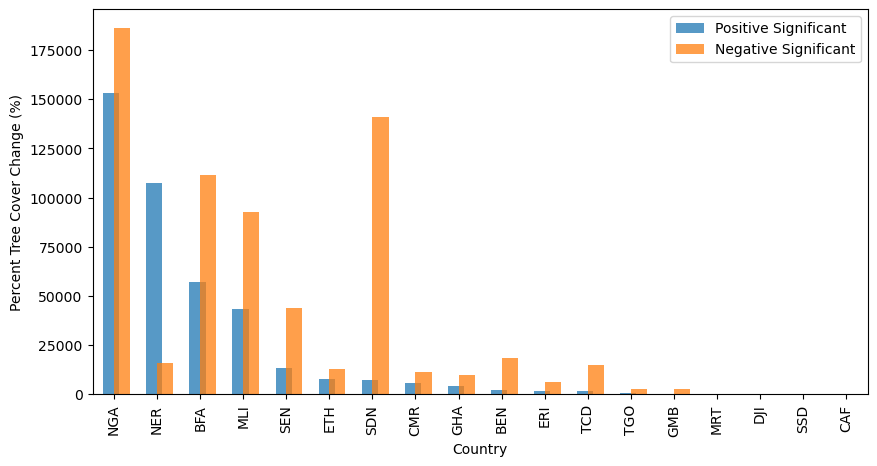

In [41]:
# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
# rank bar in order of largest
df_country.sort_values(by='pos_sig_diff', ascending=False, inplace=True)
df_country.plot(kind='bar', y=['pos_sig_diff', 'neg_sig_diff'], ax=ax, alpha=0.75)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)

plt.ylabel('Percent Tree Cover Change (%)')
plt.xlabel('Country')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()


In [55]:
canopy_change_sum = df_country.sum()
print(canopy_change_sum)

pos_sig_diff       1.102364
neg_sig_diff       2.188493
pos_nonsig_diff    0.057258
neg_nonsig_diff    0.114310
dtype: float64


pos_sig_diff                    0.227867
neg_sig_diff                    0.032847
pos_nonsig_diff                 0.018959
neg_nonsig_diff                 0.005381
country            NERNERNERNERNERNERNER
dtype: object


/tmp/ipykernel_3655805/3660414003.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_sig_diff', ascending=False, inplace=True)


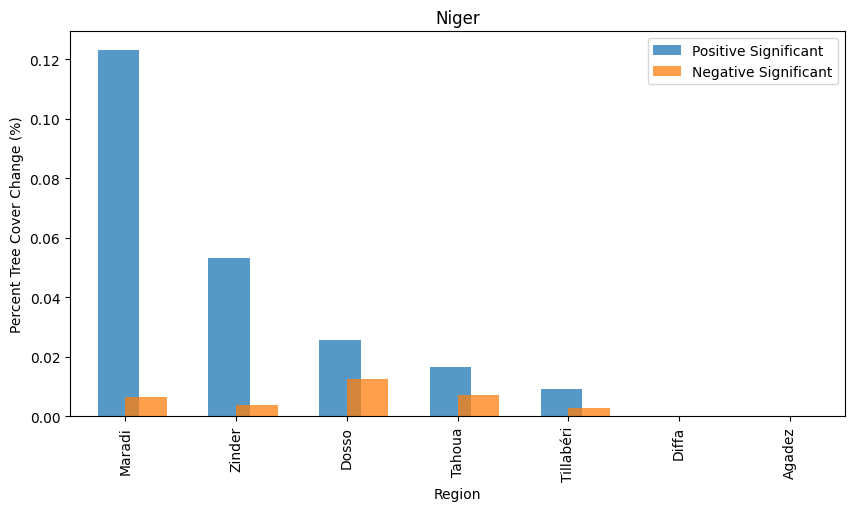

In [7]:
# group to Niger 
df_niger = df_region[df_region['country'] == 'NER']
print(df_niger.sum())

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
df_niger.sort_values(by='pos_diff_m2', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_diff_m2', 'neg_diff_m2'], ax=ax, alpha=0.75)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)
plt.title('Niger')
plt.ylabel('Percent Tree Cover Change (%)')
plt.xlabel('Region')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/niger_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3655805/375406081.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_niger.sort_values(by='pos_sig_diff', ascending=False, inplace=True)


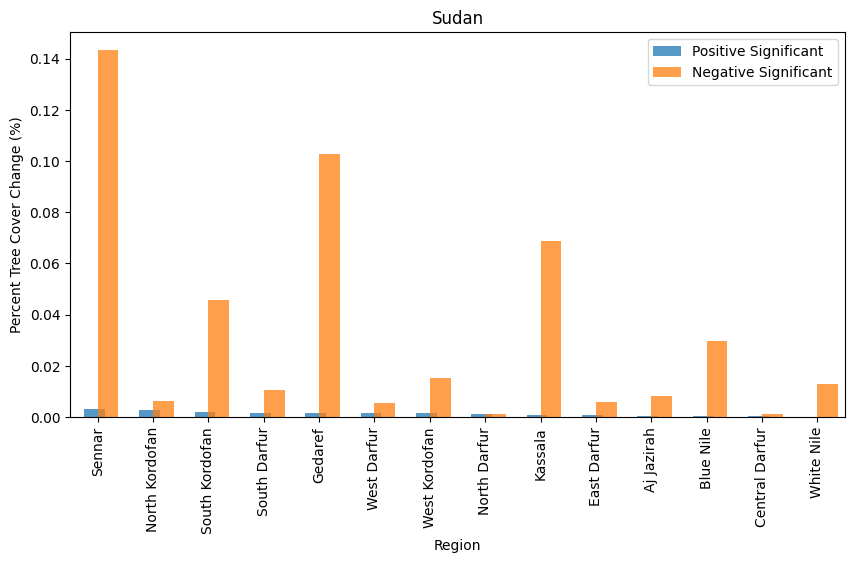

In [10]:
# group to Senegal 
df_niger = df_region[df_region['country'] == 'SDN']

# plot bar charts of pos significant, negative sigficant and total significant trends by region all on the same axis 
fig, ax = plt.subplots(figsize=(10, 5))
df_niger.sort_values(by='pos_sig_diff', ascending=False, inplace=True)
df_niger.plot(kind='bar', y=['pos_sig_diff', 'neg_sig_diff'], ax=ax, alpha=0.75)
for bar in ax.patches:
    bar.set_width(bar.get_width() * 1.5)
    
plt.title('Sudan')
plt.ylabel('Percent Tree Cover Change (%)')
plt.legend(['Positive Significant', 'Negative Significant'])
plt.xlabel('Region')
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sudan_bars_ls789_new.png', dpi=1000, bbox_inches='tight')
plt.show()

In [54]:
import geopandas as gpd

buffered = gpd.read_file("/mnt/sdc/tree_density_and_coverage/shapefiles/sahel_downloader/urban_buffer_zones_country_area_mean_diff_v7.gpkg")

In [55]:
# remove overlapping geometries
buffered_valid = buffered[buffered["_mean"].isna() == False]
buffered_valid.sort_values(by="_mean", ascending=False, inplace=True)
#buffered_valid.head(20)
print(len(buffered_valid))

408695


/tmp/ipykernel_2318727/1335615119.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  buffered_valid.sort_values(by="_mean", ascending=False, inplace=True)


In [57]:
buffered_filtered = buffered[~buffered['_mean'].isnull()]

# group by ring id and sum the mean tree cover
buffered_filtered["_mean"] = buffered_filtered["_mean"].mul(100)
buffered_filtered["area_ha"] = buffered_filtered["area"]/10000
buffered_filtered["distance_km"] = buffered_filtered["distance"]/1000
buffered_filtered['area_category'] = pd.cut(buffered_filtered['area_ha'], bins=[0, 20, 50, 100, 10000], labels=['0-20ha', '20-50ha', '50-100ha', '>100ha'])
#buffered_filtered.hist(column='area_ha', bins=100, log=True)
buffered_filtered_sum = buffered_filtered.groupby('ringId').mean()


buffered_filtered_1 = buffered_filtered[buffered_filtered['ringId'] == 1].groupby('area_category').mean()
buffered_filtered_2 = buffered_filtered[buffered_filtered['ringId'] == 2].groupby('area_category').mean()
buffered_filtered_3 = buffered_filtered[buffered_filtered['ringId'] == 3].groupby('area_category').mean()
buffered_filtered_4 = buffered_filtered[buffered_filtered['ringId'] == 4].groupby('area_category').mean()
buffered_filtered_4.head()

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy

,fid,DN,area,perimeter,ringId,distance,_mean,area_ha,distance_km
area_category,,,,,,,,,
0-20ha,364995.377438,1.000000,103504.295292,1963.476000,4.000000,2000.000000,0.060412,10.350430,2.000000
20-50ha,355643.536973,1.000000,302961.803381,4248.818808,4.000000,2000.000000,0.053548,30.296180,2.000000
50-100ha,367896.862457,1.000000,683964.757709,7896.328928,4.000000,2000.000000,0.026125,68.396476,2.000000
>100ha,380077.362651,1.000000,3138920.383493,22691.037932,4.000000,2000.000000,0.029922,313.892038,2.000000


In [58]:
buffered_filtered["distance_km"] = buffered_filtered['distance'] / 1000
buffered_filtered_1 = buffered_filtered[buffered_filtered['area_category'] == '0-20ha'].groupby('ringId').mean()
buffered_filtered_2 = buffered_filtered[buffered_filtered['area_category'] == '20-50ha'].groupby('ringId').mean()
buffered_filtered_3 = buffered_filtered[buffered_filtered['area_category'] == '50-100ha'].groupby('ringId').mean()
buffered_filtered_4 = buffered_filtered[buffered_filtered['area_category'] == '>100ha'].groupby('ringId').mean()



/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_2318727/4012430840.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  buffered_filtered_1 = buffered_filtered[buffered_filtered['area_category'] == '0-20ha'].groupby('ringId').mean()
/tmp/ipykernel_2318727/4012430840.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Ei

In [54]:
buffered_filtered_4.head()

,fid,DN,area,perimeter,distance,_mean,area_ha,distance_km
ringId,,,,,,,,
1,380225.732661,1.0,3.117306e+06,22682.555696,500.0,0.108613,311.730559,0.5
2,380348.701762,1.0,3.115973e+06,22665.100671,1000.0,0.092212,311.597315,1.0
3,380134.301421,1.0,3.141706e+06,22716.053512,1500.0,0.048399,314.170569,1.5
4,380077.362651,1.0,3.138920e+06,22691.037932,2000.0,0.029922,313.892038,2.0


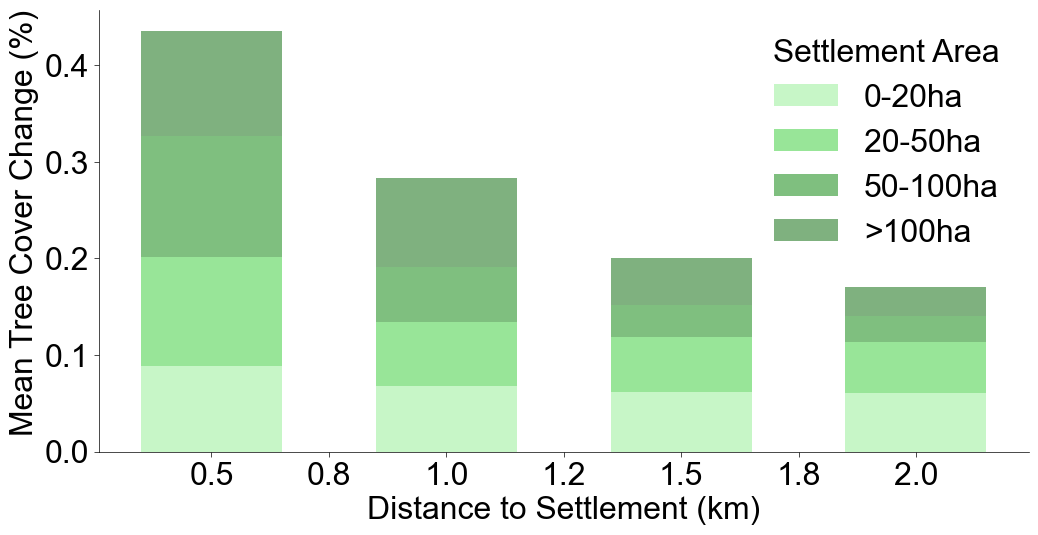

In [59]:
#plot all on same stacked bar chart
from tkinter import font
import matplotlib.pyplot as plt
import numpy as np

X_axis = [0.5, 1, 1.5, 2]

# Convert the data to lists
data_1 = buffered_filtered_1['_mean'].tolist()
data_2 = buffered_filtered_2['_mean'].tolist()
data_3 = buffered_filtered_3['_mean'].tolist()
data_4 = buffered_filtered_4['_mean'].tolist()

fix, ax = plt.subplots(figsize=(12, 6.5))
plt.rcParams['svg.fonttype'] = 'none'
# set x and y ticks to 1 decimal place
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))

# Plot the stacked bar
plt.bar(X_axis, data_1, 0.3, label='0-20ha', color="lightgreen", alpha=0.5)
plt.bar(X_axis, data_2, 0.3, bottom=data_1, label='20-50ha', color="limegreen", alpha=0.5)
plt.bar(X_axis, data_3, 0.3, bottom=np.array(data_1) + np.array(data_2), label='50-100ha', color="green", alpha=0.5)
plt.bar(X_axis, data_4, 0.3, bottom=np.array(data_1) + np.array(data_2) + np.array(data_3), label='>100ha', color="darkgreen", alpha=0.5)

#plt.xticks(X_axis, X, rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
fontsize=23
# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5, labelsize=fontsize)
ax.tick_params(axis='y', colors='black', width = 0.5, labelsize=fontsize)

# remove legend border
# increase size of legend title font

ax.legend(title= 'Settlement Area', frameon=False, fontsize=fontsize)
#legend title font size
plt.setp(ax.get_legend().get_title(), fontsize=fontsize)

plt.xlabel("Distance to Settlement (km)", fontsize=fontsize)
plt.ylabel("Mean Tree Cover Change (%)", fontsize=fontsize, loc='top')

#plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_wide_buffer_total_new_v2.png", dpi=1000, bbox_inches='tight')
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/figures/sahel_wide_buffer_total_new_v2.svg', bbox_inches='tight')
plt.show()